In [3]:
import pytest
import numpy as np
from scipy.interpolate import RectBivariateSpline

from frank2d import FourierTransform2D, rad_to_arcsec
import matplotlib.pyplot as plt

@pytest.hookimpl(trylast=True)
def pytest_terminal_summary(terminalreporter, exitstatus, config):
    """
    Hook to announce the successful completion of all atomic tests.
    This will only print if the exit status is 0 (all tests passed).
    """
    if exitstatus == 0:
        print("\n" + "="*50)
        print("🚀 FRANK2D: ALL ATOMIC TESTS PASSED SUCCESSFULLY!")
        print("="*50 + "\n")
    else:
        print("\n" + "!"*50)
        print("❌ SOME TESTS FAILED.")
        print("!"*50 + "\n")

# =============================================================================
# SYNTHETIC DATA GENERATION
# =============================================================================
def disk_with_crescent(
    N=512,                           # Image size (N x N pixels)
    pixel_scale_arcsec=0.01,         # Pixel scale (arcsec)
    sigma_core=0.04,                 # Core Gaussian width (arcsec)
    R_rings=[0.4, 0.6, 0.8],         # Rings radii (arcsec)
    width_rings=[0.05, 0.02, 0.05],  # Rings Gaussian width (arcsec)
    amp_core=0.1,                    # Core amplitude (Jy/pixel)
    amp_rings=[0.1, 0.04, 0.03],     # Rings amplitude (Jy/pixel)
    m_modes=[1, 0, 0],               # Asymmetry mode (1 -> crescent)
    theta0=[np.pi, 0, 0],            # Angle of crescent max (rad)
    amp_asym=[0.5, 0, 0]             # Asymmetry factor
    ):
    """
    Generate a synthetic disc image with non-axisymmetric substructures.

    The model follows the intensity distribution:
    $$I(R, \Phi) = I_{core}(R) + \sum I_{ring, i}(R, \Phi)$$
    
    Where asymmetries are introduced via azimuthal modulation:
    $$1 + A_{asym} \cos(m(\Phi - \theta_0))$$

    Parameters
    ----------
    N : int
        Number of pixels per side.
    pixel_scale_arcsec : float
        Angular size of each pixel.
    sigma_core : float
        Standard deviation of the central stellar/inner disc emission.
    R_rings, width_rings, amp_rings : list
        Radial parameters for the ring components.
    m_modes : list
        Order of azimuthal asymmetry (m=0 is symmetric, m=1 is a crescent).
    amp_asym : list
        Strength of the asymmetry relative to the ring's base amplitude.

    Returns
    -------
    ndarray
        2D array of shape (N, N) representing the disc brightness (Jy/pixel).
    """
    
    # --- 1. Setup Coordinate Grid ---
    x_arcsec = (np.arange(N) - N / 2) * pixel_scale_arcsec
    y_arcsec = (np.arange(N) - N / 2) * pixel_scale_arcsec
    
    X, Y = np.meshgrid(x_arcsec, y_arcsec)
    R_image = np.sqrt(X**2 + Y**2)
    Phi_image = np.arctan2(Y, X)
    
    I_disk_jy_per_pixel = np.zeros((N, N))
    
    # --- 2. Central Core Emission ---
    I_core = amp_core * np.exp(-0.5 * (R_image / sigma_core)**2)
    I_disk_jy_per_pixel += I_core
    
    # --- 3. Ring & Crescent Substructures ---
    # We iterate through each ring to apply radial profiles and 
    # optional azimuthal modulations (m-modes).
    for A, R, w, m, th0, Aasym in zip(amp_rings, R_rings,
                                      width_rings, m_modes, theta0, amp_asym):
        
        radial_profile = np.exp(-0.5 * ((R_image - R) / w)**2)
        
        if m != 0 and Aasym > 0:
            # Introducing non-axisymmetry (Strategy for spirals/vortices)
            angular_modulation = (1 + Aasym * np.cos(m * (Phi_image - th0)))
            I_component = A * radial_profile * angular_modulation
        else:
            # Standard symmetric ring
            I_component = A * radial_profile
            
        I_disk_jy_per_pixel += I_component
            
    return I_disk_jy_per_pixel

def add_vis_noise(vis, weights, seed=None):
    r"""
    Add Gaussian noise to visibilities proportional to their weights.

    Parameters
    ----------
    vis : array
        Visibilities to add noise to (complex or real).
    weights : array
        Weights on the visibilities ($1 / \sigma^2$).
    seed : int, optional
        Seed for the random number generator.

    Returns
    -------
    vis_noisy : array
        Visibilities with added noise.
    """
    if seed is not None:
        np.random.seed(seed)

    dim0 = 2 if np.iscomplexobj(vis) else 1
    vis = np.array(vis)
    
    # Noise scaled by sigma (weights**-0.5)
    noise = np.random.standard_normal((dim0,) + vis.shape)
    noise *= weights ** -0.5

    vis_noisy = vis + noise[0]
    if np.iscomplexobj(vis):
        vis_noisy += 1j * noise[1]

    return vis_noisy

# =============================================================================
# VISIBILITY SAMPLING (GALARIO-LIKE IMPLEMENTATION)
# =============================================================================

def py_sampleImage(reference_image, dxy, udat, vdat, dRA=0., dDec=0., PA=0., origin='upper'):
    """
    Original from ``galario``.
    Python implementation of sampleImage.
    
    Calculates the complex visibilities $V(u,v)$ by performing a 
    Fast Fourier Transform (FFT) and interpolating the results at 
    the requested baseline coordinates.

    Parameters
    ----------
    reference_image : ndarray
        The 2D brightness distribution (source model).
    dxy : float
        Pixel size in radians.
    udat, vdat : ndarray
        The (u,v) coordinates in wavelength units ($\lambda$).
    dRA, dDec : float, optional
        Positional offsets in arcsec.
    PA : float, optional
        Position Angle for image rotation (radians).
    origin : {'upper', 'lower'}, optional
        Coordinate system origin for the FFT shift.

    Returns
    -------
    complex ndarray
        Sampled complex visibilities corresponding to the input (u,v).
    """
    if origin == 'upper':
        v_origin = 1.
    elif origin == 'lower':
        v_origin = -1.

    nxy = reference_image.shape[0]
    dRA *= 2.*np.pi
    dDec *= 2.*np.pi
    du = 1. / (nxy*dxy)

    # --- 1. Fourier Domain Transition ---
    # Real-to-Complex FFT with appropriate shifting
    fft_r2c_shifted = np.fft.fftshift(
                        np.fft.rfft2(
                            np.fft.fftshift(reference_image)), axes=0)
    
    # --- 2. Geometric Transformations ---
    cos_PA, sin_PA = np.cos(PA), np.sin(PA)
    urot = udat * cos_PA - vdat * sin_PA
    vrot = udat * sin_PA + vdat * cos_PA
    dRArot = dRA * cos_PA - dDec * sin_PA
    dDecrot = dRA * sin_PA + dDec * cos_PA

    # --- 3. Grid Interpolation ---
    # Mapping baselines to FFT indices for linear interpolation
    uroti = np.abs(urot)/du
    vroti = nxy/2. + v_origin * vrot/du
    uneg = urot < 0.
    vroti[uneg] = nxy/2 - v_origin * vrot[uneg]/du

    u_axis = np.linspace(0., nxy // 2, nxy // 2 + 1)
    v_axis = np.linspace(0., nxy - 1, nxy)

    # Bi-linear interpolation via RectBivariateSpline
    f_re = RectBivariateSpline(v_axis, u_axis, fft_r2c_shifted.real, kx=1, ky=1, s=0)
    ReInt = f_re.ev(vroti, uroti)
    f_im = RectBivariateSpline(v_axis, u_axis, fft_r2c_shifted.imag, kx=1, ky=1, s=0)
    ImInt = f_im.ev(vroti, uroti)
    f_amp = RectBivariateSpline(v_axis, u_axis, np.abs(fft_r2c_shifted), kx=1, ky=1, s=0)
    AmpInt = f_amp.ev(vroti, uroti)

    # --- 4. Phase Correction ---
    uneg = urot < 0.
    ImInt[uneg] *= -1.
    PhaseInt = np.angle(ReInt + 1j*ImInt)

    # Apply phase shifts for RA/Dec offsets
    theta = urot*dRArot + vrot*dDecrot
    vis = AmpInt * (np.cos(theta+PhaseInt) + 1j*np.sin(theta+PhaseInt))

    return vis

# =============================================================================
# FIXTURES
# =============================================================================

DISK_PARAMETRIC_FUNCTION = disk_with_crescent

<>:38: SyntaxWarning: invalid escape sequence '\P'
<>:141: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\P'
<>:141: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1176743/3100612536.py:38: SyntaxWarning: invalid escape sequence '\P'
  """
/tmp/ipykernel_1176743/3100612536.py:141: SyntaxWarning: invalid escape sequence '\l'
  """


In [4]:
def apply_radial_dropout(weights_1d, N, protection_radius=0.3, dropout_prob=0.4, seed=None):
    """
    Applies a radial dropout mask to the weights array.
    
    The center of the uv-plane is protected (kept at 1.0), while the 
    outer regions are randomly zeroed out to simulate flagged data.

    Parameters
    ----------
    weights_1d : ndarray
        The 1D flattened weights array of size N*N.
    N : int
        Grid size per side.
    protection_radius : float
        Fraction of the radius (0 to 1) that will be protected from dropouts.
    dropout_prob : float
        Probability of zeroing out a pixel in the outer region.
    seed : int, optional
        Random seed for reproducibility.

    Returns
    -------
    ndarray
        Flattened weights array with applied radial dropouts.
    """
    if seed is not None:
        np.random.seed(seed)

    # 1. Reshape to 2D for spatial operations
    weights_2d = weights_1d.reshape((N, N))
    
    # 2. Create normalized radial coordinate system
    val = np.linspace(-1, 1, N)
    X, Y = np.meshgrid(val, val)
    R = np.sqrt(X**2 + Y**2)
    
    # 3. Define the region eligible for dropouts
    outer_mask = R > protection_radius
    
    # 4. Generate and apply the random dropout
    random_noise = np.random.random((N, N))
    dropout_mask = (random_noise < dropout_prob)
    
    # Only zero out if it is in the outer region AND selected by the probability
    weights_2d[outer_mask & dropout_mask] = 0.0
    
    return weights_2d.ravel()

In [81]:
def simulated_obs(show_plots = False):
    """
    Global fixture providing synthetic observations with radial flagging.
    """
    N = 30
    Rmax = 2.0
    
    # Generate ground truth image
    pix_scale = (2 * Rmax) / N
    image = disk_with_crescent(N=N, pixel_scale_arcsec=pix_scale)

    # Setup Fourier engine for coordinates
    Rmax_rad = Rmax / rad_to_arcsec
    FT = FourierTransform2D(Rmax_rad, N, use_gpu=False)
    u, v = FT.uv_points
    
    # Initialize weights and apply the dropout mask using the separate function
    weights = np.ones_like(u)
    #"""
    weights = apply_radial_dropout(
        weights, 
        N, 
        protection_radius=0.50, # 25% inner core protected
        dropout_prob=0.5,       # 50% chance of flagging in outskirts
        seed=46
    )
    #"""


    # Sample visibilities and add noise proportional to weights
    vis_clean = py_sampleImage(image, FT.dx, u, v)
    vis_noisy = add_vis_noise(vis_clean, weights, seed=46)
    
    if show_plots:
        plt.imshow(np.log10(np.abs(vis_noisy).reshape((N, N))), origin='lower', extent=[-Rmax, Rmax, -Rmax, Rmax])
        plt.title("Log10 of Clean Visibilities (No Noise)")
        plt.xlabel("u (lambda)")
        plt.ylabel("v (lambda)")
        plt.colorbar(label="Log10(|V|)")
        plt.show()

        plt.imshow(image, origin='lower', extent=[-Rmax, Rmax, -Rmax, Rmax])
        plt.title("Simulated Disc Image")
        plt.xlabel("RA (arcsec)")
        plt.ylabel("Dec (arcsec)")
        plt.colorbar(label="Intensity (Jy/pixel)")
        plt.show()


    return {
        'uvtable': {'u': u, 'v': v, 'vis': vis_clean, 'weights': weights},
        'N': N,
        'Rmax': Rmax
    }


In [82]:
simulated_obs()

{'uvtable': {'u': array([-773493.02342661, -721926.82186484, -670360.62030306,
         -618794.41874129, -567228.21717952, -515662.01561774,
         -464095.81405597, -412529.61249419, -360963.41093242,
         -309397.20937064, -257831.00780887, -206264.8062471 ,
         -154698.60468532, -103132.40312355,  -51566.20156177,
               0.        ,   51566.20156177,  103132.40312355,
          154698.60468532,  206264.8062471 ,  257831.00780887,
          309397.20937064,  360963.41093242,  412529.61249419,
          464095.81405597,  515662.01561774,  567228.21717952,
          618794.41874129,  670360.62030306,  721926.82186484,
         -773493.02342661, -721926.82186484, -670360.62030306,
         -618794.41874129, -567228.21717952, -515662.01561774,
         -464095.81405597, -412529.61249419, -360963.41093242,
         -309397.20937064, -257831.00780887, -206264.8062471 ,
         -154698.60468532, -103132.40312355,  -51566.20156177,
               0.        ,   51566.2015

In [83]:
    # --- 1. Extraction from Fixture ---
    data = simulated_obs()
    uvtable = data['uvtable']
    N = data['N']
    Rmax = data['Rmax']

    # --- 2. Initialization of both mediators ---
    # We pass use_gpu=False (CPU) and use_gpu=True (GPU)
    from frank2d import Frank2D
    model_cpu = Frank2D(N, Rmax, use_gpu=False)
    model_gpu = Frank2D(N, Rmax, use_gpu=True)

In [84]:
model_cpu.process_vis(uvtable)
#model_gpu.process_vis(uvtable)

===>  Setting gridded data...


In [85]:
u, v = model_cpu.gridded_data['u'], model_cpu.gridded_data['v']
vis = model_cpu.gridded_data['vis']
weights = model_cpu.gridded_data['weights']

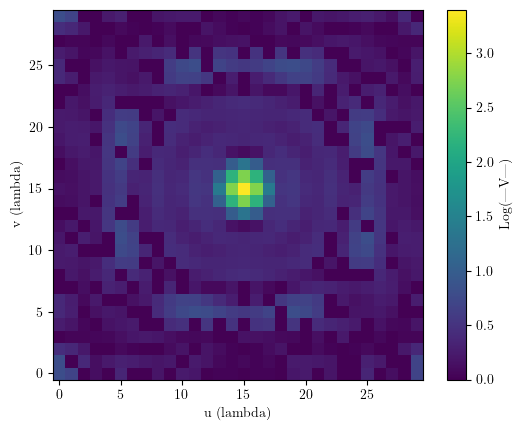

In [86]:
plt.imshow(np.abs(vis.reshape((N, N))), origin='lower')
plt.xlabel("u (lambda)")
plt.ylabel("v (lambda)")
plt.colorbar(label="Log(|V|)")
plt.show()

In [87]:
model_cpu.fit(rtol=1e-10)
#model_gpu.fit(rtol=1e-10)

===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2, 'c': 100000000.0, 'l': 50000.0}
Updating m to  -2
Updating c to  100000000.0
Updating l to  50000.0
===>  Creating sparse linear system...
        +  Kernel = 0.00  min |  0.02 seconds
        +  Building system = 0.00  min |  0.02 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 4/50000 [00:00<52:51, 15.77 iterations/s]

            +  BiCGStab = 0.00  min |  0.26 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 4.4552430738245145e-09,
 'iterations': 4,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
Updating m to  -2
Updating c to  100000000.0
Updating l to  50000.0
     + Setting kernel..
Updating m to  -2
Updating c to  100000000.0
Updating l to  50000.0
--> time building S_12_T = 0.00  min |  0.01 seconds
--> times building full visibility model = 0.00  min |  0.01 seconds
